# Projet Commodities — Stratégies sur l'indice S&P GSCI ER

**Auteurs :** *Yassine Mannai, Issam Fradi & Antonin Bezard*  
**Master :** *MSc 272 - Parcours Quant*  
**Année universitaire :** *2025-2026*

---

In [1]:
# ――― Imports ――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings('ignore')

In [2]:
# ――― Paramètres ――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
DATA_DIR    = os.path.dirname(os.path.abspath('__file__'))
DATA_PATH   = os.path.join(DATA_DIR, 'data')
OUTPUT_PATH = os.path.join(DATA_DIR, 'output')

os.makedirs(DATA_PATH,   exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)

START_DATE = '19691231'
END_DATE   = '20251231'
EXCEL_PATH = os.path.join(DATA_PATH, 'GSCI_Data.xlsx')

TICKERS = {
    'SPGSCI Index':   'GSCI_Spot',   # S&P GSCI Spot
    'SPGSCIP Index':  'GSCI_ER',     # S&P GSCI Excess Return
    'SPGSCITR Index': 'GSCI_TR',     # S&P GSCI Total Return
}

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

---
## Q1 — Données historiques des 3 indices S&P GSCI

Les données sont récupérées via l'**API Bloomberg (blpapi)** sur la période 31/12/1969 – 31/12/2025.

| Indice | Ticker Bloomberg |
|---|---|
| S&P GSCI Spot | `SPGSCI Index` |
| S&P GSCI ER (Excess Return) | `SPGSCIP Index` |
| S&P GSCI TR (Total Return) | `SPGSCITR Index` |

In [3]:
# ――― Fonction Bloomberg ―――――――――――――――――――――――――――――――――――――――――――――――――――――
def bdh_bbg(tickers: dict, field: str, start: str, end: str) -> pd.DataFrame:
    """
    Récupère l'historique de cours depuis Bloomberg via blpapi.
    """
    import blpapi
    
    session_options = blpapi.SessionOptions()
    session_options.setServerHost('localhost')
    session_options.setServerPort(8194)

    session = blpapi.Session(session_options)
    if not session.start():
        raise ConnectionError('Impossible de démarrer la session Bloomberg')
    if not session.openService('//blp/refdata'):
        session.stop()
        raise ConnectionError("Impossible d'ouvrir le service //blp/refdata")

    ref_data_svc = session.getService('//blp/refdata')
    request = ref_data_svc.createRequest('HistoricalDataRequest')

    for ticker in tickers:
        request.getElement('securities').appendValue(ticker)
    request.getElement('fields').appendValue(field)
    request.set('startDate', start)
    request.set('endDate', end)
    request.set('periodicitySelection', 'DAILY')
    request.set('nonTradingDayFillOption', 'NON_TRADING_WEEKDAYS')
    request.set('nonTradingDayFillMethod', 'PREVIOUS_VALUE')

    session.sendRequest(request)

    raw = {name: {} for name in tickers.values()}

    while True:
        event = session.nextEvent(2000)
        for msg in event:
            if not msg.hasElement('securityData'):
                continue
            sec_data   = msg.getElement('securityData')
            bbg_ticker = sec_data.getElementAsString('security')
            col_name   = tickers.get(bbg_ticker)
            if col_name is None:
                continue
            if sec_data.hasElement('securityError'):
                continue
            field_data = sec_data.getElement('fieldData')
            for i in range(field_data.numValues()):
                row  = field_data.getValue(i)
                date = row.getElementAsDatetime('date')
                if row.hasElement(field):
                    raw[col_name][date] = row.getElementAsFloat(field)

        if event.eventType() == blpapi.Event.RESPONSE:
            break

    session.stop()

    df_out = pd.DataFrame(raw)
    df_out.index = pd.to_datetime(df_out.index)
    df_out.sort_index(inplace=True)
    return df_out


def save_to_excel(df_data: pd.DataFrame, path: str) -> None:
    """Exporte le DataFrame vers Excel avec mise en forme."""
    from openpyxl.styles import Font, PatternFill, Alignment
    df_exp = df_data[['GSCI_Spot', 'GSCI_ER', 'GSCI_TR']].copy()
    df_exp.index.name = 'Date'
    with pd.ExcelWriter(path, engine='openpyxl', date_format='DD/MM/YYYY') as writer:
        df_exp.to_excel(writer, sheet_name='Données GSCI')
        ws = writer.sheets['Données GSCI']
        for col_letter, width in zip(['A', 'B', 'C', 'D'], [14, 14, 14, 14]):
            ws.column_dimensions[col_letter].width = width
        header_fill = PatternFill(start_color='1F4E79', end_color='1F4E79', fill_type='solid')
        header_font = Font(bold=True, color='FFFFFF')
        for cell in ws[1]:
            cell.font      = header_font
            cell.fill      = header_fill
            cell.alignment = Alignment(horizontal='center')
        for row in ws.iter_rows(min_row=2, min_col=2, max_col=4):
            for cell in row:
                cell.number_format = '#,##0.0000'
    print(f'  Fichier Excel enregistré : {path}')

In [4]:
# ――― Chargement des données ―――――――――――――――――――――――――――――――――――――――――――――――――
if os.path.exists(EXCEL_PATH):
    print(f'Fichier Excel trouvé — chargement depuis {EXCEL_PATH}...')
    df = pd.read_excel(EXCEL_PATH, sheet_name='Données GSCI', index_col='Date', parse_dates=True)
    df = df.sort_index()
    df.columns = [c.strip() for c in df.columns]
    missing_cols = [c for c in ['GSCI_Spot', 'GSCI_ER', 'GSCI_TR'] if c not in df.columns]
    if missing_cols:
        raise ValueError(f'Colonnes manquantes dans le fichier Excel : {missing_cols}')
    print(f'  Excel chargé : {len(df)} lignes  ({df.index[0].date()} → {df.index[-1].date()})')
    DATA_SOURCE = f'Excel ({EXCEL_PATH})'
else:
    print('Pas de fichier Excel — connexion au Terminal Bloomberg...')
    df = bdh_bbg(TICKERS, field='PX_LAST', start=START_DATE, end=END_DATE)
    missing_cols = [c for c in ['GSCI_Spot', 'GSCI_ER', 'GSCI_TR']
                    if c not in df.columns or df[c].isna().all()]
    if missing_cols:
        raise ValueError(f'Colonnes vides ou manquantes après Bloomberg : {missing_cols}')
    print(f'  Bloomberg chargé : {len(df)} lignes  ({df.index[0].date()} → {df.index[-1].date()})')
    DATA_SOURCE = 'Bloomberg'
    save_to_excel(df, EXCEL_PATH)

print(f'\nSource : {DATA_SOURCE}')
print(f'Aperçu :')
df.tail()

Fichier Excel trouvé — chargement depuis c:\Users\b304juv\Desktop\Trading Commo\data\GSCI_Data.xlsx...
  Excel chargé : 14609 lignes  (1970-01-02 → 2025-12-31)

Source : Excel (c:\Users\b304juv\Desktop\Trading Commo\data\GSCI_Data.xlsx)
Aperçu :


,GSCI_Spot,GSCI_ER,GSCI_TR
Date,,,
2025-12-25,554.5012,306.7441,3956.176
2025-12-26,550.4011,304.4759,3927.706
2025-12-29,551.3090,304.9781,3935.357
2025-12-30,554.2844,306.6241,3956.988
2025-12-31,548.5183,303.4344,3916.219


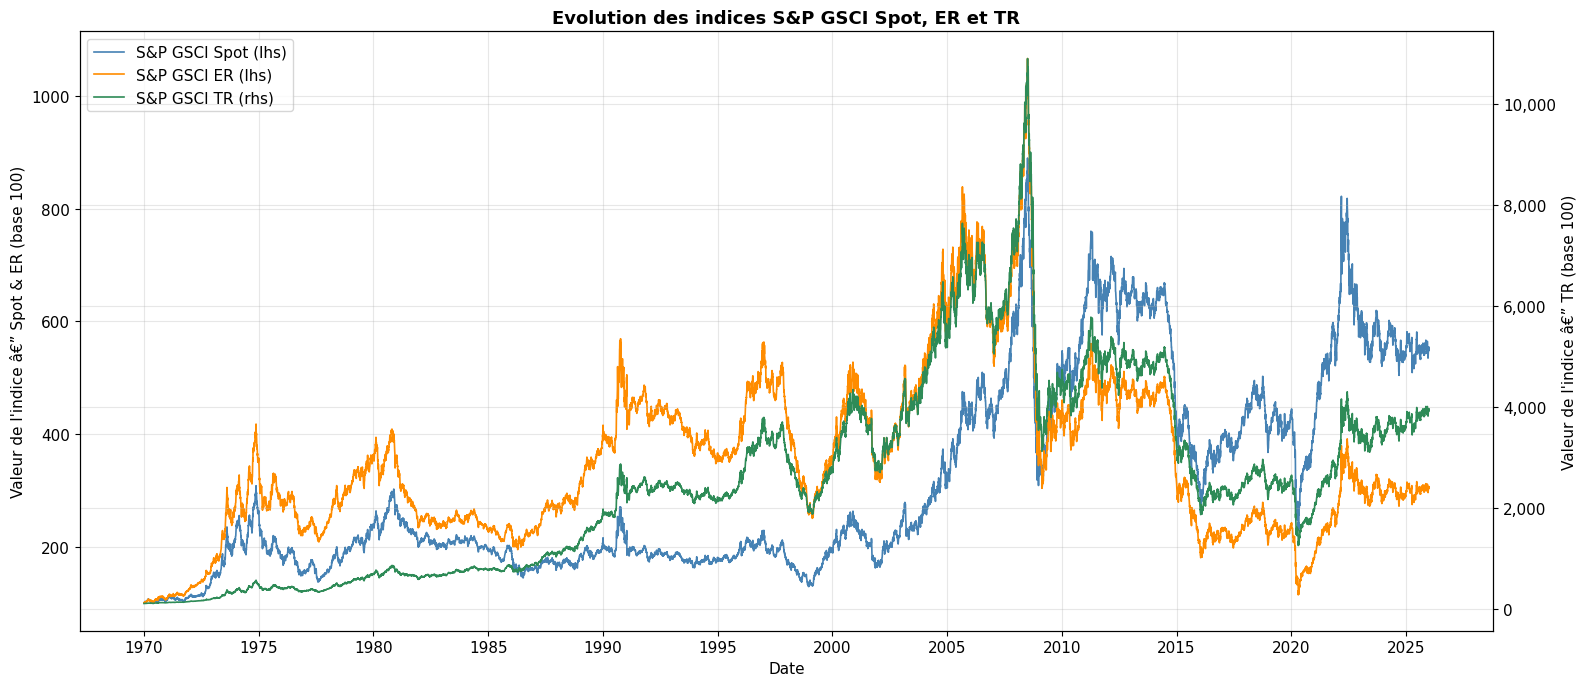

Graphique enregistrÃ© : Q1_indices.png


In [ ]:
# ――― Q1 — Graphique des 3 indices (base 100 au 31/12/1969) ――――――――――――――――――
df_idx     = df[['GSCI_Spot', 'GSCI_ER', 'GSCI_TR']].dropna()
df_rebased = df_idx / df_idx.iloc[0] * 100

fig, ax1 = plt.subplots(figsize=(16, 7))

# Axe gauche : Spot et ER
l1, = ax1.plot(df_rebased.index, df_rebased['GSCI_Spot'], label='S&P GSCI Spot', color='steelblue',  linewidth=1.2)
l2, = ax1.plot(df_rebased.index, df_rebased['GSCI_ER'],   label='S&P GSCI ER',   color='darkorange', linewidth=1.2)
ax1.set_xlabel('Date')
ax1.set_ylabel('Valeur de l\'indice - Spot & ER (base 100)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.xaxis.set_major_locator(mdates.YearLocator(5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Axe droit : TR
ax2 = ax1.twinx()
l3, = ax2.plot(df_rebased.index, df_rebased['GSCI_TR'], label='S&P GSCI TR', color='seagreen', linewidth=1.2, linestyle='-')
ax2.set_ylabel('Valeur de l\'indice - TR (base 100)')
ax2.tick_params(axis='y')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Légende commune
ax1.legend(handles=[l1, l2, l3], labels=['S&P GSCI Spot (lhs)', 'S&P GSCI ER (lhs)', 'S&P GSCI TR (rhs)'],
           fontsize=11, loc='upper left')

ax1.set_title('Evolution des indices S&P GSCI Spot, ER et TR', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'Q1_indices.png'), dpi=150)
plt.show()
print('Graphique enregistré : Q1_indices.png')

---
## Q2 — Métriques de performance sur 31/12/1969 – 31/12/2025

Pour chacun des 3 indices :
- **Rendement cumulé** = $\frac{P_T - P_0}{P_0}$
- **Rendement actuariel** (CAGR) = $\left(\frac{P_T}{P_0}\right)^{\frac{1}{N}} - 1$ avec $N$ = nombre d'années
- **Volatilité annualisée** = $\sigma_{\text{journalier}} \times \sqrt{252}$
- **Ratio Rendement/Volatilité** = $\frac{\text{CAGR}}{\text{Volatilité annualisée}}$

In [6]:
# ――― Fonction de métriques de performance ―――――――――――――――――――――――――――――――――――
def performance_metrics(price_series: pd.Series, ann_factor: int = 252) -> dict:
    """Calcule les métriques de performance à partir d'une série de prix."""
    s = price_series.dropna()
    n_years = (s.index[-1] - s.index[0]).days / 365.25
    daily_returns = s.pct_change().dropna()
    
    cumul_return = (s.iloc[-1] / s.iloc[0]) - 1
    cagr = (s.iloc[-1] / s.iloc[0]) ** (1 / n_years) - 1
    vol_ann = daily_returns.std() * np.sqrt(ann_factor)
    ratio = cagr / vol_ann if vol_ann != 0 else np.nan
    
    return {
        'Rendement cumulé':           f'{cumul_return:.1%}',
        'Rendement actuariel (CAGR)': f'{cagr:.2%}',
        'Volatilité annualisée':      f'{vol_ann:.2%}',
        'Ratio Rdt / Vol':            f'{ratio:.4f}',
    }

# ――― Q2 — Tableau comparatif ―――――――――――――――――――――――――――――――――――――――――――――――
metrics = {}
for col in ['GSCI_Spot', 'GSCI_ER', 'GSCI_TR']:
    metrics[col] = performance_metrics(df[col])

df_metrics = pd.DataFrame(metrics).T
df_metrics.index = ['S&P GSCI Spot', 'S&P GSCI ER', 'S&P GSCI TR']
print('=' * 90)
print('Q2 — PERFORMANCE (31/12/1969 - 31/12/2025)')
print('=' * 90)
print(df_metrics.to_string())
print('=' * 90)

Q2 — PERFORMANCE (31/12/1969 - 31/12/2025)
              Rendement cumulé Rendement actuariel (CAGR) Volatilité annualisée Ratio Rdt / Vol
S&P GSCI Spot           448.5%                      3.09%                19.16%          0.1610
S&P GSCI ER             203.4%                      2.00%                19.12%          0.1047
S&P GSCI TR            3816.2%                      6.77%                19.12%          0.3541


---
## Q3 — Explication des différences de rendement

### Spot vs ER (Excess Return)

L'indice **Spot** reflète la variation du **prix au comptant** des matières premières (pondérées par la production mondiale).  
L'indice **ER (Excess Return)** intègre en plus la composante de **roll yield**, qui représente le coût (ou bénéfice) du renouvellement des contrats futures :

$$\text{GSCI ER} = \text{GSCI Spot} + \underbrace{\text{Roll Yield}}_{\text{coût de portage}}$$

En **backwardation** (prix spot > prix futures), le roll yield est positif.  
En **contango** (prix spot < prix futures), le roll yield est négatif.  

Sur longue période, les matières premières sont majoritairement en **contango**, ce qui explique que le GSCI ER sous-performe structurellement le GSCI Spot.

### ER vs TR (Total Return)

L'indice **TR (Total Return)** ajoute à l'ER le **rendement du collatéral** (intérêts sur les T-bills US déposés en garantie) :

$$\text{GSCI TR} = \text{GSCI ER} + \underbrace{\text{Collateral Return}}_{\approx \text{taux sans risque}}$$

Historiquement, les taux courts américains ont été en moyenne proches de **4–5 % par an**, ce qui explique la surperformance significative du TR versus l'ER sur longue période.

---
## Q4 — Méthode de calcul automatique de la Moyenne Mobile

La **moyenne mobile simple (MMS)** sur $n$ jours en date $t$ est :

$$\text{MA}_n(t) = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}$$

La cellule ci-dessous propose une fonction générique réplicable sur n'importe quel historique et n'importe quelle fenêtre.

In [7]:
# ――― Q4 — Fonction de calcul de moyenne mobile ――――――――――――――――――――――――――――――
def moving_average(price_series: pd.Series, window: int) -> pd.Series:
    """
    Moyenne mobile simple sur `window` jours.
    Équivalent Excel : =AVERAGE(P[n]:P[n-window+1])
    """
    return price_series.rolling(window=window, min_periods=window).mean()

# Test rapide
ma50_test = moving_average(df['GSCI_ER'], 50)
print(f'MA50 — Dernières 5 valeurs :')
print(ma50_test.tail())
print(f'\nPremière valeur non-NaN : {ma50_test.first_valid_index()}')

MA50 — Dernières 5 valeurs :
Date
2025-12-25    304.425742
2025-12-26    304.573834
2025-12-29    304.679846
2025-12-30    304.848508
2025-12-31    304.910224
Name: GSCI_ER, dtype: float64

Première valeur non-NaN : 1970-03-12 00:00:00


---
## Q5 — Calcul des 5 moyennes mobiles (25, 50, 100, 150, 200 jours)

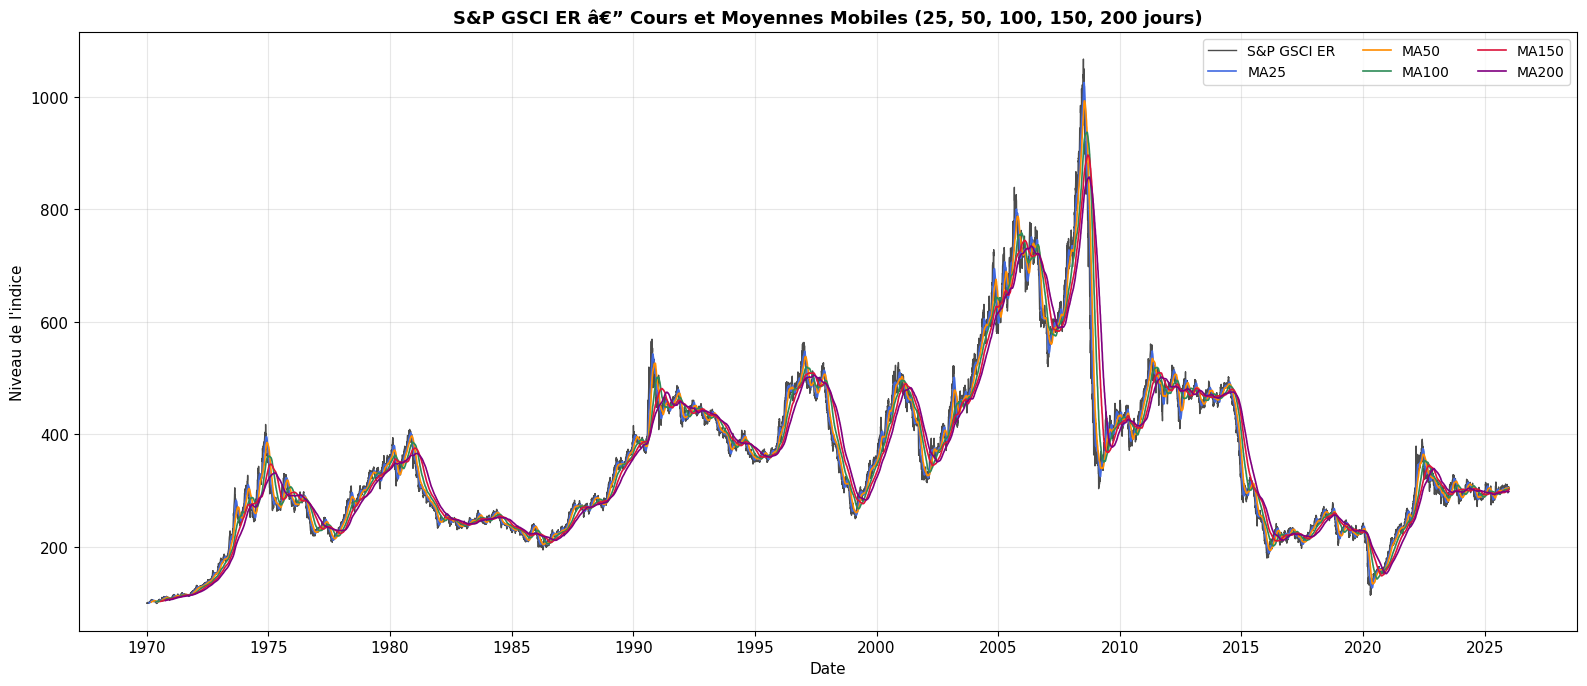

Graphique enregistrÃ© : Q5_moving_averages.png


In [ ]:
# ――― Q5 — Calcul des 5 MAs sur le GSCI ER ――――――――――――――――――――――――――――――――――――
WINDOWS = [25, 50, 100, 150, 200]

er = df['GSCI_ER'].dropna().copy()

ma_dict = {}
for w in WINDOWS:
    ma_dict[w] = moving_average(er, w)

# ―― Graphique : GSCI ER + 5 MAs ――――――――――――――――――――――――――――――――――――――――――――――
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(er.index, er, label='S&P GSCI ER', color='black', linewidth=1.0, alpha=0.7)

colors = ['royalblue', 'darkorange', 'seagreen', 'crimson', 'purple']
for w, col in zip(WINDOWS, colors):
    ax.plot(ma_dict[w].index, ma_dict[w], label=f'MA{w}', color=col, linewidth=1.2)

ax.set_title('S&P GSCI ER - Cours et Moyennes Mobiles (25, 50, 100, 150, 200 jours)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Niveau de l\'indice')
ax.legend(fontsize=10, ncol=3)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'Q5_moving_averages.png'), dpi=150)
plt.show()
print('Graphique enregistré : Q5_moving_averages.png')

---
## Q6 — Backtest des 5 stratégies Moyenne Mobile

**Règle du signal :**
- **Signal achat (position = 1)** : le cours de clôture dépasse à la hausse sa moyenne mobile → $P_t > \text{MA}_n(t)$
- **Signal neutre (position = 0)** : sinon (pas de vente à découvert)

Chaque stratégie génère un **indice de valeur 100 au 31/12/1969** en appliquant les rendements journaliers uniquement lors des jours en position *achat*.

In [9]:
# ――― Q6 ― Backtest : construction des 5 indices MA ―――――――――――――――――――――――――
def backtest_ma_strategy(price: pd.Series, window: int) -> pd.Series:
    """
    Construit un indice de stratégie MA :
    - Position = 1 (long) quand price[t-1] > MA[t-1]  (signal calculé veille)
    - Position = 0 sinon
    - L'indice démarre à 100 à la première date disponible.
    """
    ma = moving_average(price, window)
    # Signal décalé d'un jour pour éviter le look-ahead bias
    signal = (price.shift(1) > ma.shift(1)).astype(int)
    
    daily_ret = price.pct_change()
    strat_ret = signal * daily_ret
    
    # On commence après avoir suffisamment d'historique pour la MA
    strat_ret_clean = strat_ret.iloc[window:]
    
    index_vals = 100.0 * (1 + strat_ret_clean).cumprod()
    # Compléter avec 100 pour les premières dates (période sans signal)
    prefix = pd.Series(100.0, index=price.index[:window])
    index_vals = pd.concat([prefix, index_vals])
    return index_vals

# Construction des indices stratégies
strat_indices = {}
for w in WINDOWS:
    strat_indices[w] = backtest_ma_strategy(er, w)
    print(f'MA{w:3d} — Indice calculé ({len(strat_indices[w])} points)')

print('\nBacktest terminé.')

MA 25 — Indice calculé (14609 points)
MA 50 — Indice calculé (14609 points)
MA100 — Indice calculé (14609 points)
MA150 — Indice calculé (14609 points)
MA200 — Indice calculé (14609 points)

Backtest terminé.


In [10]:
# ――― Q6 — Métriques de performance des 5 stratégies ――――――――――――――――――――――――――
def performance_from_index(index_series: pd.Series, ann_factor: int = 252) -> dict:
    """Métriques depuis un indice synthétique rebasé."""
    s = index_series.dropna()
    n_years = (s.index[-1] - s.index[0]).days / 365.25

    cumul = (s.iloc[-1] / s.iloc[0]) - 1
    cagr  = (s.iloc[-1] / s.iloc[0]) ** (1 / n_years) - 1

    daily_ret = s.pct_change().dropna()
    # Volatilité calculée uniquement sur les jours de position active
    vol_ann = daily_ret[daily_ret != 0].std() * np.sqrt(ann_factor)
    ratio   = cagr / vol_ann if vol_ann != 0 else np.nan

    return {
        'Rendement cumulé':           f'{cumul:.1%}',
        'Rendement actuariel (CAGR)': f'{cagr:.2%}',
        'Volatilité annualisée':      f'{vol_ann:.2%}',
        'Ratio Rdt / Vol':            f'{ratio:.4f}',
    }

# Référence : GSCI ER buy-and-hold
bh_metrics = performance_metrics(er)

rows = {'GSCI ER (Buy & Hold)': bh_metrics}
for w in WINDOWS:
    rows[f'Stratégie MA{w}'] = performance_from_index(strat_indices[w])

df_q6 = pd.DataFrame(rows).T
print('=' * 80)
print('Q6 — PERFORMANCE DES 5 STRATÉGIES MA vs GSCI ER BUY & HOLD')
print('=' * 80)
print(df_q6.to_string())
print('=' * 80)

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
Q6 â€” PERFORMANCE DES 5 STRATÃ‰GIES MA vs GSCI ER BUY & HOLD
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
                     Rendement cumulé Rendement actuariel (CAGR) Volatilité annualisée Ratio Rdt / Vol Rendement cumulÃ© VolatilitÃ© annualisÃ©e
GSCI ER (Buy & Hold)           203.4%                      2.00%                19.12%          0.1047               NaN                     NaN
StratÃ©gie MA25                   NaN                      5.15%                   NaN          0.2821           1561.2%                  18.25%
StratÃ©gie MA50      

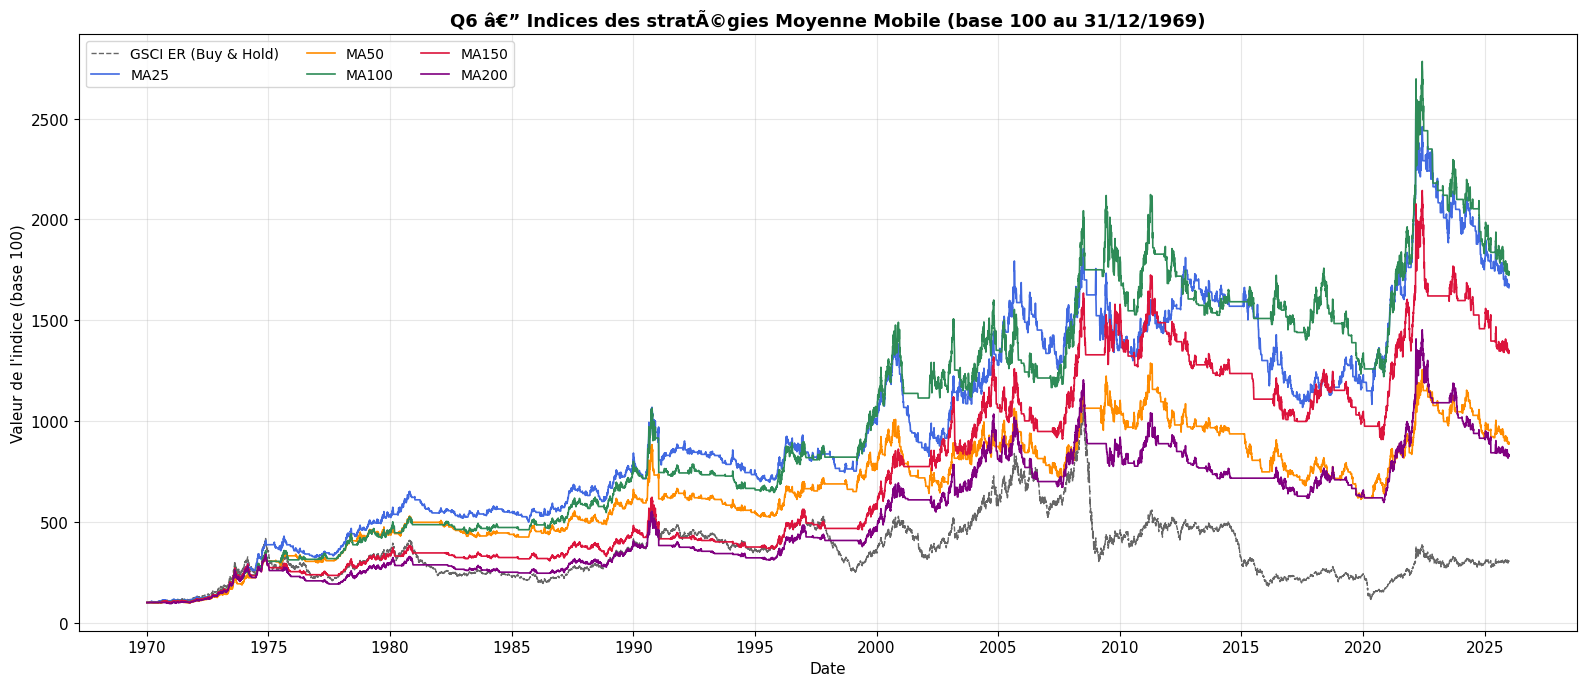

Graphique enregistrÃ© : Q6_strategies.png


In [ ]:
# ――― Q6 — Graphique des 5 indices stratégie ――――――――――――――――――――――――――――――――――
fig, ax = plt.subplots(figsize=(16, 7))

# GSCI ER rebased à 100
er_rebased = er / er.iloc[0] * 100
ax.plot(er_rebased.index, er_rebased, label='GSCI ER (Buy & Hold)', color='black', linewidth=1.0, alpha=0.6, linestyle='--')

for w, col in zip(WINDOWS, colors):
    ax.plot(strat_indices[w].index, strat_indices[w], label=f'MA{w}', color=col, linewidth=1.2)

ax.set_title('Q6 - Indices des stratégies Moyenne Mobile (base 100 au 31/12/1969)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Valeur de l\'indice (base 100)')
ax.legend(fontsize=10, ncol=3)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'Q6_strategies.png'), dpi=150)
plt.show()
print('Graphique enregistré : Q6_strategies.png')

---
## Q7 — Portefeuille équi-pondéré des 5 stratégies MA

Le portefeuille combine les 5 stratégies avec un poids égal de $\frac{1}{5}$ chacune.  
À chaque instant $t$, le rendement du portefeuille vaut :

$$r_{\text{portef}}(t) = \frac{1}{5} \sum_{k \in \{25,50,100,150,200\}} r_k(t)$$

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
Q7 â€” PERFORMANCE DU PORTEFEUILLE Ã‰QUI-PONDÃ‰RÃ‰ (5 stratÃ©gies MA)
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
  Rendement cumulÃ©                   1231.7%
  Rendement actuariel (CAGR)          4.73%
  VolatilitÃ© annualisÃ©e             14.60%
  Ratio Rdt / Vol                     0.3243
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•


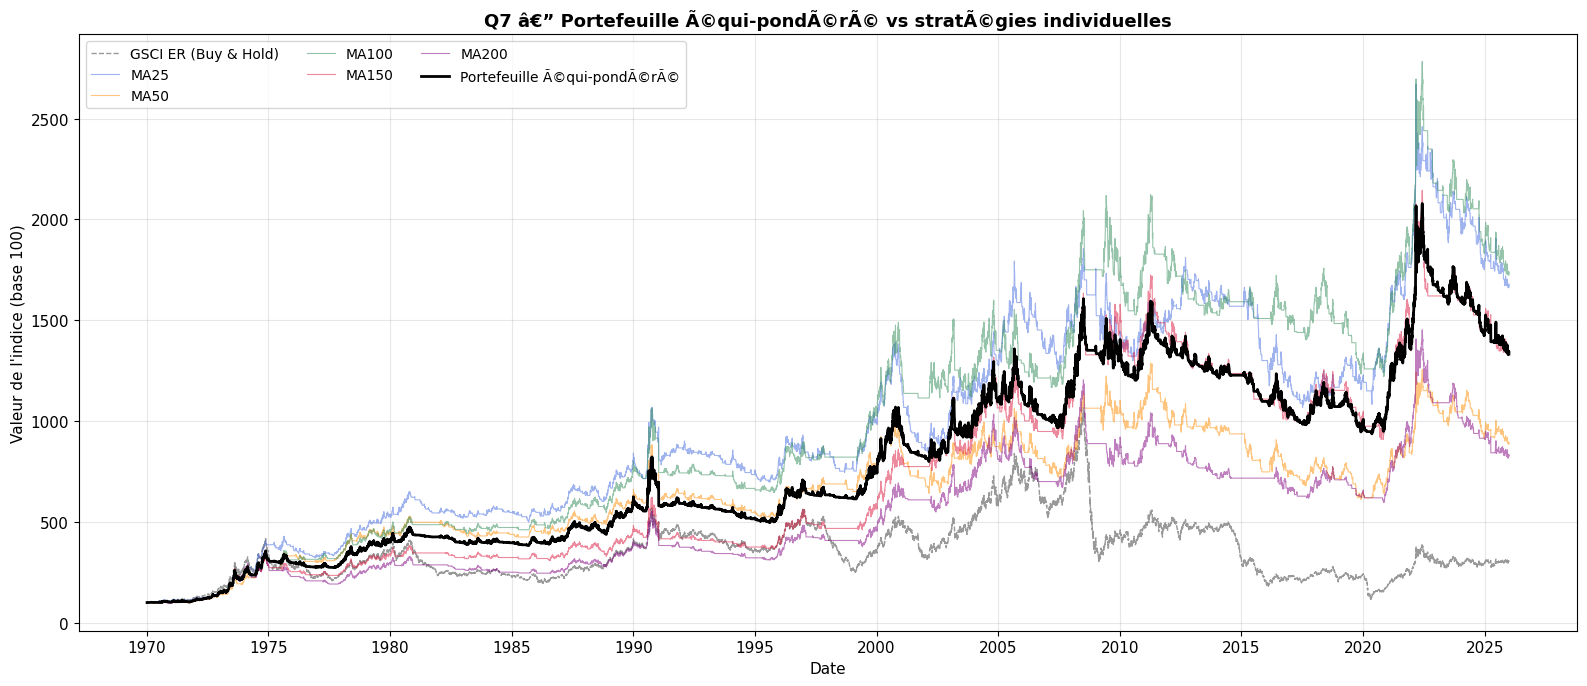

Graphique enregistrÃ© : Q7_portfolio.png


In [12]:
# ――― Q7 — Portefeuille équi-pondéré des 5 stratégies ―――――――――――――――――――――――――
strat_returns = pd.DataFrame({f'MA{w}': strat_indices[w].pct_change() for w in WINDOWS}).dropna(how='all')

# Rendement quotidien du portefeuille = moyenne simple des 5 stratégies
port_ret = strat_returns.mean(axis=1)

# Construire l'indice du portefeuille (base 100)
port_index = 100.0 * (1 + port_ret.fillna(0)).cumprod()

# ―― Métriques ――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
port_perf = performance_from_index(port_index)

print('=' * 70)
print('Q7 — PERFORMANCE DU PORTEFEUILLE ÉQUI-PONDÉRÉ (5 stratégies MA)')
print('=' * 70)
for k, v in port_perf.items():
    print(f'  {k:<35} {v}')
print('=' * 70)

# ―― Graphique ――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(er_rebased.index, er_rebased, label='GSCI ER (Buy & Hold)', color='gray', linewidth=1.0, linestyle='--', alpha=0.8)
for w, col in zip(WINDOWS, colors):
    ax.plot(strat_indices[w].index, strat_indices[w], label=f'MA{w}', color=col, linewidth=0.8, alpha=0.5)
ax.plot(port_index.index, port_index, label='Portefeuille équi-pondéré', color='black', linewidth=2.0)

ax.set_title('Q7 — Portefeuille équi-pondéré vs stratégies individuelles', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Valeur de l\'indice (base 100)')
ax.legend(fontsize=10, ncol=3)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'Q7_portfolio.png'), dpi=150)
plt.show()
print('Graphique enregistré : Q7_portfolio.png')

---
## Q8 — Stratégie améliorée : Croisement de Moyennes Mobiles + Filtre RSI

### Logique de la stratégie

La stratégie combine **deux signaux** pour améliorer le ratio rendement/volatilité :

1. **Signal 1 — Croisement de moyennes mobiles (MA50 / MA200)** :  
   Signal achat = 1 si $\text{MA50}(t) > \text{MA200}(t)$ (Golden Cross), sinon 0.

2. **Signal 2 — Filtre RSI (14 jours)** :  
   $$\text{RSI} = 100 - \frac{100}{1 + RS} \quad \text{où} \quad RS = \frac{\text{Moyenne des hausses (14j)}}{\text{Moyenne des baisses (14j)}}$$  
   - Filtre actif si RSI > 30 (on évite les positions en cas de survente extrême)  
   - Filtre actif si RSI < 70 (on évite les entrées en zone de surachat)

**Signal final = Signal MA × Signal RSI**  
(Position = 1 uniquement si les deux conditions sont remplies simultanément)

In [ ]:
# ――― Q8 — Indicateurs techniques ―――――――――――――――――――――――――――――――――――――――――――――
def compute_rsi(price: pd.Series, period: int = 14) -> pd.Series:
    """Calcule le RSI (Relative Strength Index) sur `period` jours."""
    delta = price.diff()
    gain  = delta.clip(lower=0)
    loss  = (-delta).clip(lower=0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    rs  = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi


def backtest_enhanced_strategy(
    price: pd.Series,
    fast_window: int = 50,
    slow_window: int = 200,
    rsi_period: int = 14,
    rsi_low: float = 30,
    rsi_high: float = 70,
) -> pd.Series:
    """
    Stratégie combinée : Croisement MA + Filtre RSI.
    - Long si MA_fast > MA_slow ET rsi_low < RSI < rsi_high
    - Neutre sinon
    """
    ma_fast = moving_average(price, fast_window)
    ma_slow = moving_average(price, slow_window)
    rsi     = compute_rsi(price, rsi_period)

    # Signaux (décalés d'un jour)
    signal_ma  = (ma_fast.shift(1) > ma_slow.shift(1)).astype(int)
    signal_rsi = ((rsi.shift(1) > rsi_low) & (rsi.shift(1) < rsi_high)).astype(int)
    signal     = (signal_ma * signal_rsi)

    daily_ret  = price.pct_change()
    strat_ret  = signal * daily_ret

    index_vals = 100.0 * (1 + strat_ret.fillna(0)).cumprod()
    return index_vals, signal, rsi


# ―― Calcul de la stratégie améliorée ―――――――――――――――――――――――――――――――――――――――――
enhanced_idx, signal_series, rsi_series = backtest_enhanced_strategy(er)

# ―― Métriques comparatives ――――――――――――――――――――――――――――――――――――――――――――――――――
enhanced_perf = performance_from_index(enhanced_idx)

print('=' * 75)
print('Q8 — COMPARAISON : Stratégie Améliorée vs Portefeuille Équi-pondéré vs Buy & Hold')
print('=' * 75)
rows_q8 = {
    'GSCI ER (Buy & Hold)':          performance_metrics(er),
    'Portefeuille équi-pondéré (Q7)': port_perf,
    'Stratégie MA50/200 + RSI':       enhanced_perf,
}
df_q8 = pd.DataFrame(rows_q8).T
print(df_q8.to_string())
print('=' * 75)

â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
Q8 â€” COMPARAISON : StratÃ©gie AmÃ©liorÃ©e vs Portefeuille Ã‰qui-pondÃ©rÃ© vs Buy & Hold
â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
                                  Rendement cumulé Rendement actuariel (CAGR) Volatilité annualisée Ratio Rdt / Vol Rendement cumulÃ© VolatilitÃ© annualisÃ©e
GSCI ER (Buy & Hold)                        203.4%                      2.00%                19.12%          0.1047               NaN                     NaN
Portefeuille Ã©qui-pondÃ©rÃ© (Q7)              NaN                      4.73%                   NaN          0.3243           1231.7%         

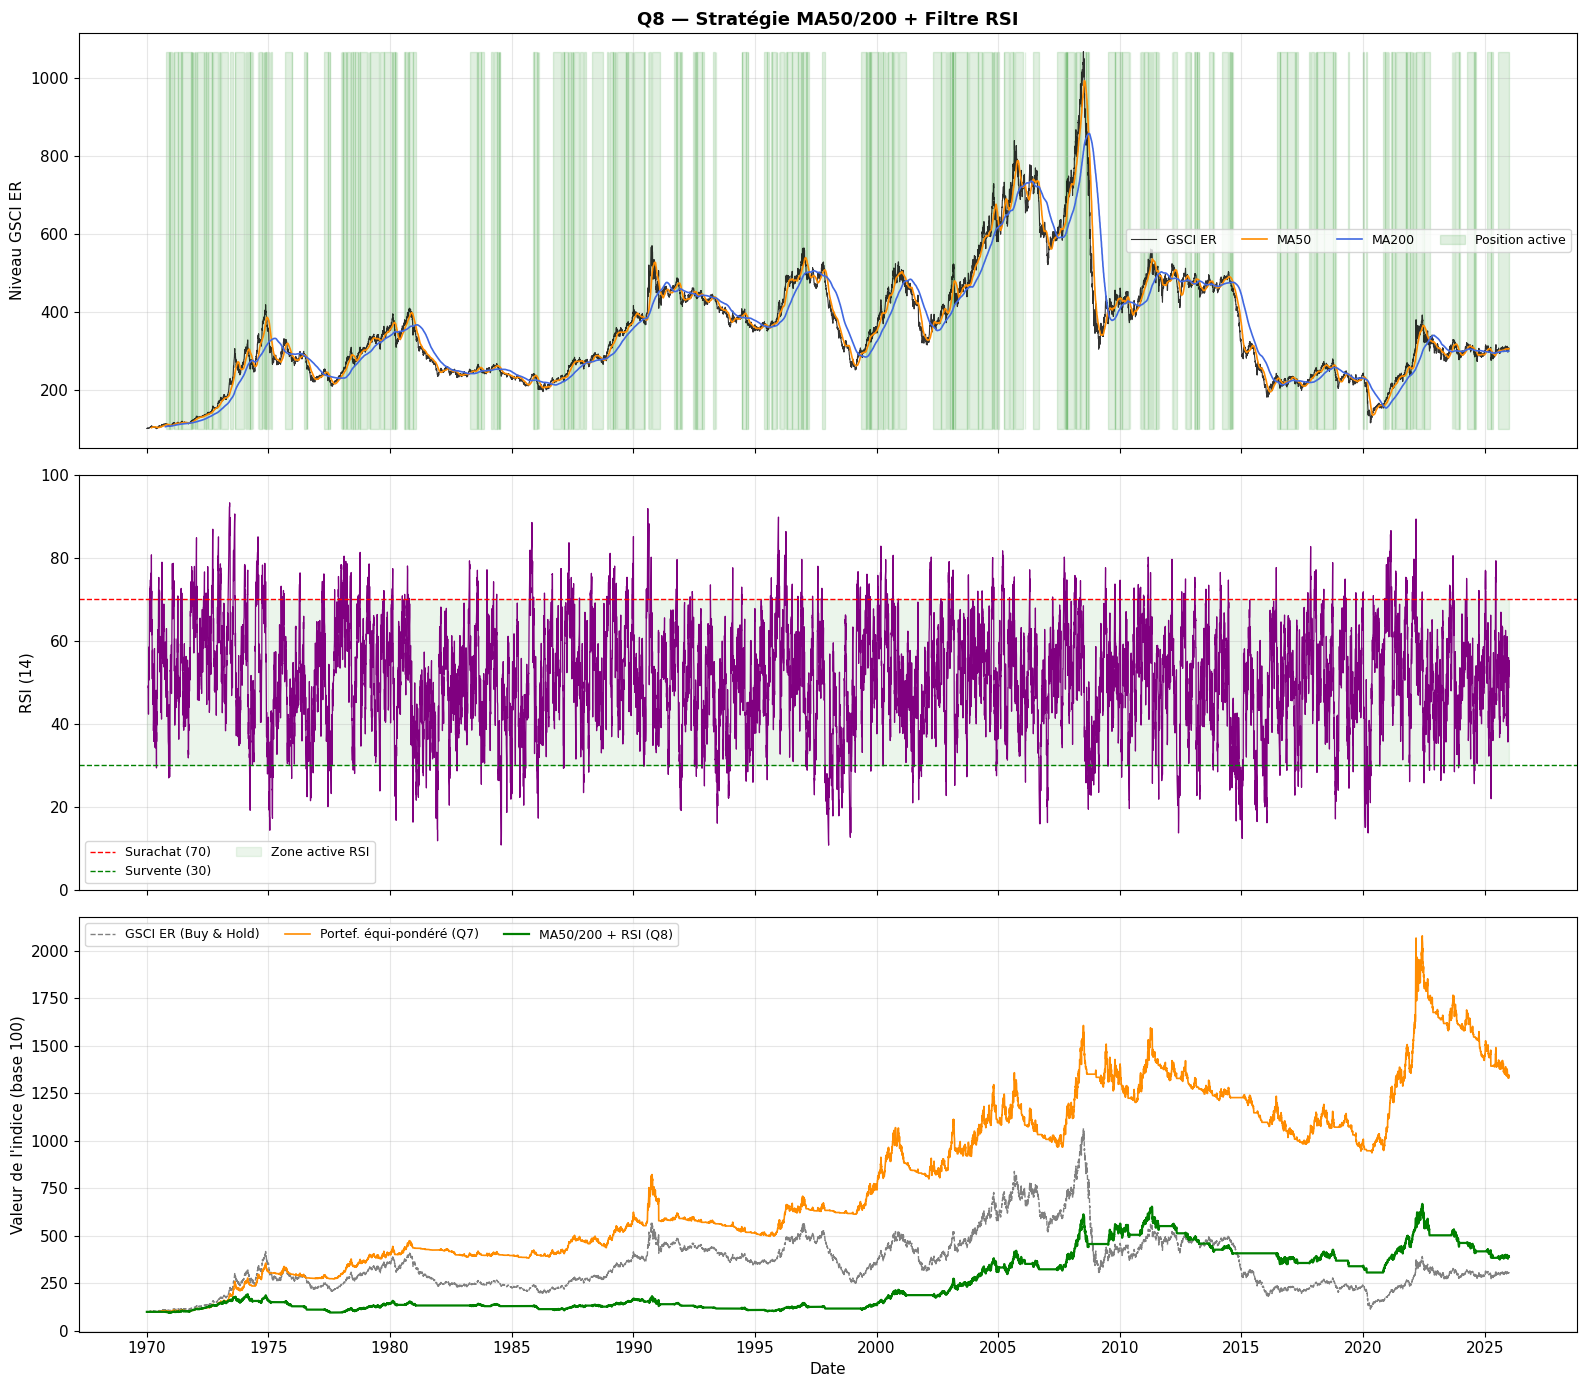

Graphique enregistrÃ© : Q8_enhanced_strategy.png


In [ ]:
# ――― Q8 — Graphique stratégie améliorée ――――――――――――――――――――――――――――――――――――――
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

# Panel 1 : Cours + MAs
ax0 = axes[0]
ax0.plot(er.index, er, color='black', linewidth=0.8, label='GSCI ER', alpha=0.8)
ax0.plot(ma_dict[50].index,  ma_dict[50],  color='darkorange', linewidth=1.2, label='MA50')
ax0.plot(ma_dict[200].index, ma_dict[200], color='royalblue',  linewidth=1.2, label='MA200')
ax0.fill_between(signal_series.index, er.min(), er.max(),
                 where=signal_series == 1, alpha=0.12, color='green', label='Position active')
ax0.set_ylabel('Niveau GSCI ER')
ax0.set_title('Q8 — Stratégie MA50/200 + Filtre RSI', fontsize=13, fontweight='bold')
ax0.legend(fontsize=9, ncol=4)

# Panel 2 : RSI
ax1 = axes[1]
ax1.plot(rsi_series.index, rsi_series, color='purple', linewidth=0.9)
ax1.axhline(70, color='red',   linestyle='--', linewidth=1, label='Surachat (70)')
ax1.axhline(30, color='green', linestyle='--', linewidth=1, label='Survente (30)')
ax1.fill_between(rsi_series.index, 30, 70, alpha=0.08, color='green', label='Zone active RSI')
ax1.set_ylim(0, 100)
ax1.set_ylabel('RSI (14)')
ax1.legend(fontsize=9, ncol=2)

# Panel 3 : Performance cumulative
ax2 = axes[2]
ax2.plot(er_rebased.index, er_rebased,    label='GSCI ER (Buy & Hold)', color='gray', linestyle='--', linewidth=1.0)
ax2.plot(port_index.index, port_index,     label='Portef. équi-pondéré (Q7)', color='darkorange', linewidth=1.2)
ax2.plot(enhanced_idx.index, enhanced_idx, label='MA50/200 + RSI (Q8)', color='green', linewidth=1.6)
ax2.set_ylabel('Valeur de l\'indice (base 100)')
ax2.set_xlabel('Date')
ax2.legend(fontsize=9, ncol=3)
ax2.xaxis.set_major_locator(mdates.YearLocator(5))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'Q8_enhanced_strategy.png'), dpi=150)
plt.show()
print('Graphique enregistré : Q8_enhanced_strategy.png')

---
## Résumé synthétique

In [ ]:
# ――― Tableau récapitulatif final ――――――――――――――――――――――――――――――――――――――――――――――
all_rows = {
    'S&P GSCI Spot':                 performance_metrics(df['GSCI_Spot']),
    'S&P GSCI ER (Buy & Hold)':      performance_metrics(er),
    'S&P GSCI TR':                   performance_metrics(df['GSCI_TR']),
}
for w in WINDOWS:
    all_rows[f'Stratégie MA{w}'] = performance_from_index(strat_indices[w])

all_rows['Portefeuille équi-pondéré (Q7)'] = port_perf
all_rows['Stratégie MA50/200 + RSI (Q8)']  = enhanced_perf

df_final = pd.DataFrame(all_rows).T
print('=' * 80)
print('  TABLEAU RÉCAPITULATIF COMPLET — Projet Commodities 2026')
print('=' * 80)
print(df_final.to_string())
print('=' * 80)

â•”â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•—
  TABLEAU RÃ‰CAPITULATIF COMPLET â€” Projet Commodities 2026
â•‘â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â•‘
                               Rendement cumulÃ© Rendement actuariel (CAGR) VolatilitÃ© annualisÃ©e Ratio Rdt / Vol
S&P GSCI Spot                            448.5%                      3.09%                19.16%          0.1610
S&P GSCI ER (Buy & Hold)                 203.4%                      2.00%                19.12%          0.1047
S&P GSCI TR                             3816.2%                      6.77%                19.12%       

---
## Notes méthodologiques

- **Données** : récupérées via l'API Bloomberg (`blpapi`) — tickers `SPGSCI Index`, `SPGSCIP Index`, `SPGSCITR Index`. Fallback depuis fichier Excel si le Terminal Bloomberg n'est pas disponible.
- **No look-ahead bias** : tous les signaux sont calculés avec un décalage d'un jour (`shift(1)`) pour reproduire la décision du soir J appliquée en J+1.
- **Coûts de transaction** : non pris en compte (comme demandé dans l'énoncé).
- **Volatilité des stratégies** : calculée uniquement sur les jours de position active (rendements ≠ 0).

---
## Exports — Excel des résultats & Rapport Word

In [ ]:
# ――― Export Excel — Tous les résultats ――――――――――――――――――――――――――――――――――――――――
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows

RESULTS_EXCEL = os.path.join(OUTPUT_PATH, 'Resultats_GSCI_2026.xlsx')

thin_border = Border(
    left=Side(style='thin'), right=Side(style='thin'),
    top=Side(style='thin'), bottom=Side(style='thin')
)

def style_sheet(ws, df, title=None):
    """Applique un style propre à une feuille Excel."""
    header_fill = PatternFill(start_color='1F4E79', end_color='1F4E79', fill_type='solid')
    header_font = Font(bold=True, color='FFFFFF', size=10)
    alt_fill = PatternFill(start_color='DEEAF1', end_color='DEEAF1', fill_type='solid')
    
    # Style en-tête
    for cell in ws[1]:
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = Alignment(horizontal='center', vertical='center')
        cell.border = thin_border
    
    # Style corps + alternance de lignes
    for i, row in enumerate(ws.iter_rows(min_row=2, max_row=ws.max_row, max_col=ws.max_column), start=0):
        for cell in row:
            cell.alignment = Alignment(horizontal='center')
            cell.border = thin_border
            if i % 2 == 1:
                cell.fill = alt_fill
    
    # Largeur auto
    for col in ws.columns:
        max_len = max(len(str(cell.value or '')) for cell in col) + 2
        ws.column_dimensions[col[0].column_letter].width = min(max_len, 25)

with pd.ExcelWriter(RESULTS_EXCEL, engine='openpyxl') as writer:
    # Feuille 1 : Q2 — Métriques des 3 indices
    df_metrics.to_excel(writer, sheet_name='Q2_Indices')
    style_sheet(writer.sheets['Q2_Indices'], df_metrics)
    
    # Feuille 2 : Q6 — Stratégies MA
    df_q6.to_excel(writer, sheet_name='Q6_Strategies_MA')
    style_sheet(writer.sheets['Q6_Strategies_MA'], df_q6)
    
    # Feuille 3 : Q7 — Portefeuille équi-pondéré
    df_q7_export = pd.DataFrame([port_perf], index=['Portefeuille équi-pondéré'])
    df_q7_export.to_excel(writer, sheet_name='Q7_Portefeuille')
    style_sheet(writer.sheets['Q7_Portefeuille'], df_q7_export)
    
    # Feuille 4 : Q8 — Stratégie améliorée
    df_q8.to_excel(writer, sheet_name='Q8_Strategie_Amelioree')
    style_sheet(writer.sheets['Q8_Strategie_Amelioree'], df_q8)
    
    # Feuille 5 : Récapitulatif complet
    df_final.to_excel(writer, sheet_name='Recapitulatif')
    style_sheet(writer.sheets['Recapitulatif'], df_final)

print(f'Fichier Excel des résultats : {RESULTS_EXCEL}')
print(f'  → 5 feuilles : Q2_Indices, Q6_Strategies_MA, Q7_Portefeuille, Q8_Strategie_Amelioree, Recapitulatif')

âœ” Document Word gÃ©nÃ©rÃ© : c:\Users\b304juv\Desktop\Trading Commo\Rapport_GSCI_2026.docx


In [ ]:
# ――― Export Word — Rapport explicatif ――――――――――――――――――――――――――――――――――――――――
from docx import Document
from docx.shared import Pt, Cm, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.oxml.ns import qn
from docx.oxml import OxmlElement

WORD_PATH = os.path.join(OUTPUT_PATH, 'Rapport_GSCI_2026.docx')

# ―― Helpers ――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
def set_cell_bg(cell, hex_color: str):
    tc = cell._tc
    tcPr = tc.get_or_add_tcPr()
    shd = OxmlElement('w:shd')
    shd.set(qn('w:val'), 'clear')
    shd.set(qn('w:color'), 'auto')
    shd.set(qn('w:fill'), hex_color)
    tcPr.append(shd)

def style_header_row(table, bg='1F4E79', fg='FFFFFF'):
    for cell in table.rows[0].cells:
        set_cell_bg(cell, bg)
        for para in cell.paragraphs:
            for run in para.runs:
                run.bold = True
                run.font.color.rgb = RGBColor.from_string(fg)
                run.font.size = Pt(10)
        cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

def add_df_table(doc, df, col_widths=None):
    """Insère un DataFrame en tant que tableau Word."""
    headers = [''] + list(df.columns)
    table = doc.add_table(rows=1 + len(df), cols=len(headers))
    table.style = 'Table Grid'
    table.alignment = WD_TABLE_ALIGNMENT.CENTER
    for j, h in enumerate(headers):
        cell = table.cell(0, j)
        cell.text = str(h)
        cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
    for i, (idx, row_data) in enumerate(df.iterrows(), start=1):
        table.cell(i, 0).text = str(idx)
        for j, val in enumerate(row_data, start=1):
            cell = table.cell(i, j)
            cell.text = str(val)
            cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
    style_header_row(table)
    for i in range(1, len(df) + 1):
        if i % 2 == 0:
            for cell in table.rows[i].cells:
                set_cell_bg(cell, 'DEEAF1')
    if col_widths:
        for j, width in enumerate(col_widths):
            for row in table.rows:
                row.cells[j].width = Cm(width)
    return table

def add_image_if_exists(doc, path, width=Cm(16)):
    if os.path.exists(path):
        doc.add_picture(path, width=width)
        doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER

def h1(doc, text):
    p = doc.add_heading(text, level=1)
    p.runs[0].font.color.rgb = RGBColor(0x1F, 0x4E, 0x79)

def h2(doc, text):
    p = doc.add_heading(text, level=2)
    p.runs[0].font.color.rgb = RGBColor(0x2E, 0x75, 0xB6)

def body(doc, text):
    p = doc.add_paragraph(text)
    p.paragraph_format.space_after = Pt(6)
    return p

# ―― Création du document ―――――――――――――――――――――――――――――――――――――――――――――――――――――
doc = Document()
style = doc.styles['Normal']
style.font.name = 'Calibri'
style.font.size = Pt(11)

# ══ PAGE DE TITRE ══════════════════════════════════════════════════════════════
doc.add_paragraph()
title = doc.add_paragraph()
title.alignment = WD_ALIGN_PARAGRAPH.CENTER
run = title.add_run('Projet Commodities 2026\nStratégies sur l\'indice S&P GSCI ER')
run.bold = True
run.font.size = Pt(22)
run.font.color.rgb = RGBColor(0x1F, 0x4E, 0x79)

doc.add_paragraph()
sub = doc.add_paragraph()
sub.alignment = WD_ALIGN_PARAGRAPH.CENTER
sub.add_run('Université Paris Dauphine — Master Finance\n').font.size = Pt(13)
sub.add_run('Période analysée : 31/12/1969 – 31/12/2025\n').font.size = Pt(12)
sub.add_run('Auteurs : Yassine Mannai, Issam Fradi & Antonin Bezard').font.size = Pt(12)

doc.add_paragraph()
date_p = doc.add_paragraph('Mai 2026')
date_p.alignment = WD_ALIGN_PARAGRAPH.CENTER
date_p.runs[0].italic = True
doc.add_page_break()

# ══ Q1 ════════════════════════════════════════════════════════════════════════
h1(doc, 'Q1 — Données historiques des 3 indices S&P GSCI')
body(doc,
    'Les données journalières ont été récupérées via l\'API Bloomberg (blpapi) sur la période '
    '31/12/1969 – 31/12/2025, puis exportées dans un fichier Excel.')

tbl_tickers = doc.add_table(rows=4, cols=2)
tbl_tickers.style = 'Table Grid'
tbl_tickers.alignment = WD_TABLE_ALIGNMENT.CENTER
for j, h_text in enumerate(['Indice', 'Ticker Bloomberg']):
    tbl_tickers.cell(0, j).text = h_text
data_t = [
    ('S&P GSCI Spot', 'SPGSCI Index'),
    ('S&P GSCI ER (Excess Return)', 'SPGSCIP Index'),
    ('S&P GSCI TR (Total Return)', 'SPGSCITR Index'),
]
for i, (name, ticker) in enumerate(data_t, start=1):
    tbl_tickers.cell(i, 0).text = name
    tbl_tickers.cell(i, 1).text = ticker
style_header_row(tbl_tickers)

doc.add_paragraph()
body(doc, 'Le graphique ci-dessous présente les 3 indices rebasés à 100 au 31/12/1969.')
add_image_if_exists(doc, os.path.join(OUTPUT_PATH, 'Q1_indices.png'))
doc.add_page_break()

# ══ Q2 ════════════════════════════════════════════════════════════════════════
h1(doc, 'Q2 — Métriques de performance (1969 – 2025)')
body(doc, 'Pour chacun des 3 indices, les métriques suivantes ont été calculées :')
for item in ['Rendement cumulé', 'Rendement actuariel (CAGR)', 'Volatilité annualisée', 'Ratio Rendement / Volatilité']:
    doc.add_paragraph(item, style='List Bullet')
doc.add_paragraph()
add_df_table(doc, df_metrics, col_widths=[5, 4, 4, 4, 3.5])
doc.add_page_break()

# ══ Q3 ════════════════════════════════════════════════════════════════════════
h1(doc, 'Q3 — Explication des différences de rendement')
h2(doc, 'Spot vs ER (Excess Return)')
body(doc,
    'L\'indice Spot reflète la variation du prix au comptant. L\'indice ER intègre en plus '
    'le roll yield (coût du renouvellement des contrats futures). En contango (situation '
    'majoritaire sur longue période), le roll yield est négatif, ce qui explique que le '
    'GSCI ER sous-performe structurellement le GSCI Spot.')

h2(doc, 'ER vs TR (Total Return)')
body(doc,
    'L\'indice TR ajoute à l\'ER le rendement du collatéral (intérêts sur les T-bills US). '
    'Historiquement ~4-5% par an, ce qui explique la surperformance du TR sur longue période.')
doc.add_page_break()

# ══ Q4 & Q5 ═══════════════════════════════════════════════════════════════════
h1(doc, 'Q4 & Q5 — Moyennes Mobiles')
body(doc, 'La moyenne mobile simple (MMS) sur n jours est : MA_n(t) = (1/n) × Σ P(t−i)')
body(doc, '5 MAs calculées : 25, 50, 100, 150 et 200 jours.')
add_image_if_exists(doc, os.path.join(OUTPUT_PATH, 'Q5_moving_averages.png'))
doc.add_page_break()

# ══ Q6 ════════════════════════════════════════════════════════════════════════
h1(doc, 'Q6 — Backtest des 5 stratégies Moyenne Mobile')
body(doc,
    'Signal achat : P(t) > MA_n(t). Signal neutre sinon. '
    'Décalage d\'un jour pour éviter le look-ahead bias.')
h2(doc, 'Résultats')
add_df_table(doc, df_q6, col_widths=[5, 4, 4, 4, 3.5])
doc.add_paragraph()
add_image_if_exists(doc, os.path.join(OUTPUT_PATH, 'Q6_strategies.png'))
doc.add_page_break()

# ══ Q7 ════════════════════════════════════════════════════════════════════════
h1(doc, 'Q7 — Portefeuille équi-pondéré des 5 stratégies MA')
body(doc, 'Combinaison des 5 stratégies avec un poids de 1/5 chacune.')
tbl_q7 = doc.add_table(rows=len(port_perf) + 1, cols=2)
tbl_q7.style = 'Table Grid'
tbl_q7.alignment = WD_TABLE_ALIGNMENT.CENTER
for j, h_text in enumerate(['Métrique', 'Valeur']):
    tbl_q7.cell(0, j).text = h_text
for i, (k, v) in enumerate(port_perf.items(), start=1):
    tbl_q7.cell(i, 0).text = k
    tbl_q7.cell(i, 1).text = v
style_header_row(tbl_q7)
doc.add_paragraph()
add_image_if_exists(doc, os.path.join(OUTPUT_PATH, 'Q7_portfolio.png'))
doc.add_page_break()

# ══ Q8 ════════════════════════════════════════════════════════════════════════
h1(doc, 'Q8 — Stratégie améliorée : MA50/MA200 + Filtre RSI')
body(doc, 'La stratégie combine deux signaux :')
doc.add_paragraph('Signal MA : position longue si MA50 > MA200 (Golden Cross)', style='List Number')
doc.add_paragraph('Filtre RSI : position uniquement si 30 < RSI(14) < 70', style='List Number')
body(doc, 'Signal final = Signal MA × Signal RSI')
h2(doc, 'Comparaison des performances')
add_df_table(doc, df_q8, col_widths=[6, 4, 4, 4, 3.5])
doc.add_paragraph()
add_image_if_exists(doc, os.path.join(OUTPUT_PATH, 'Q8_enhanced_strategy.png'))
doc.add_page_break()

# ══ RÉCAPITULATIF ═════════════════════════════════════════════════════════════
h1(doc, 'Tableau récapitulatif complet')
body(doc, 'Comparaison de toutes les stratégies sur la période 31/12/1969 – 31/12/2025.')
add_df_table(doc, df_final, col_widths=[5.5, 4, 4, 4, 3.5])
doc.add_page_break()

# ══ NOTES ═════════════════════════════════════════════════════════════════════
h1(doc, 'Notes méthodologiques')
notes = [
    'Données : API Bloomberg (blpapi) — export automatique en Excel.',
    'No look-ahead bias : signaux décalés d\'un jour (shift(1)).',
    'Coûts de transaction : non pris en compte.',
    'Volatilité des stratégies : calculée sur les jours de position active uniquement.',
    'Logiciel : Python 3, pandas, numpy, matplotlib, openpyxl, python-docx.',
]
for note in notes:
    doc.add_paragraph(note, style='List Bullet')

# ―― Sauvegarde ―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
doc.save(WORD_PATH)
print(f'Rapport Word généré : {WORD_PATH}')